<a href="https://colab.research.google.com/github/vcardui/RealTimeCharacterDetection/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# +----------------------------------------------------------------------------+
# | CARDUI TECH v1.0.0
# +----------------------------------------------------------------------------+
# | Copyright (c) 2026 - 2026, CARDUITECH.COM (www.carduitech.com)
# | Vanessa Reteguín <vanessa@reteguin.com>
# | Released under the MIT license
# | www.carduitech.com/license/
# +----------------------------------------------------------------------------+
# | Author.......: Vanessa Reteguín <vanessa@reteguin.com>
# | First release: September 16th, 2026
# | Last update..: September 16th, 2026
# | Course.......: Automatons II
# | WhatIs.......: Real Time Character Detection - Main
# +----------------------------------------------------------------------------++
# ------------------------- Instructions -----------------------
# Instrucciones: crea una CNN para clasificar caracteres (conjunto de datos
# "mnist" o "emnist"). Utiliza la red para detectar caracteres en tiempo real.

# ---

# - Detection de caracteres en tiempo real
# - Palabra por palabra vs carácter a carácter

#    Hola = hola = hola.

# - Justificar uso de modelo: Transformer? CNN? Otra?
# - Conclusiones
# - *Entrenar por partes -> Check points

# ------------ Resources / Documentation involved -------------
# MNIST Dataset: https://www.kaggle.com/datasets/hojjatk/mnist-dataset

# Deep learning on MNIST: https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/

# MNIST Dataset in Python: Complete Guide with Examples:
# https://www.digitalocean.com/community/tutorials/mnist-dataset-in-python$0

# 1. Authenticate with Kaggle API to download datasets

In [ ]:
!pip install kaggle -q

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

!rm -rf ~/.kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 62 bytes
/root/.kaggle/kaggle.json


In [68]:
# ------------------------- Libraries -------------------------
import kagglehub # kagglehub.dataset_download(DATASET_ID)

import os  # os.path.exists(path)

import cv2 # camera

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# ------------------------- Variables -------------------------
# DATASET_FOLDER = 'input/mnist-dataset/'
DATASET_ID = 'hojjatk/mnist-dataset'

data_sources = {
    "training_images": "train-images-idx3-ubyte",  # 60,000 training images.
    "test_images": "t10k-images-idx3-ubyte",  # 10,000 test images.
    "training_labels": "train-labels-idx1-ubyte",  # 60,000 training labels.
    "test_labels": "t10k-labels-idx1-ubyte",  # 10,000 test labels.
}

In [ ]:

DATASET_FOLDER = kagglehub.dataset_download(DATASET_ID)
print(DATASET_FOLDER)

100%|██████████| 22.0M/22.0M [00:02<00:00, 9.63MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


Save images and labels into mnist_dataset dictionary as 1D arrays (neural network will expect a 1D array)

Since each image is 28 x 28 pixels, each file is reshaped into a 1 x 784 array

rb = raw binary

In [ ]:
mnist_dataset = {}

for key in ("training_images", "test_images"):
    with open(os.path.join(DATASET_FOLDER, f'{data_sources[key]}/{data_sources[key]}'), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(
            mnist_file.read(), np.uint8, offset=16
        ).reshape(-1, 28 * 28)

for key in ("training_labels", "test_labels"):
    with open(os.path.join(DATASET_FOLDER, f'{data_sources[key]}/{data_sources[key]}'), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

Split dataset into training and set test

In [ ]:
x_train, y_train, x_test, y_test = (
    mnist_dataset["training_images"],
    mnist_dataset["training_labels"],
    mnist_dataset["test_images"],
    mnist_dataset["test_labels"],
)

print(f"""Dataset shapes:
training_images (x_train): {x_train.shape}
training labels (y_train): {y_train.shape}

test images (x_test): {x_test.shape}
test labels (y_test): {y_test.shape}
""")

Dataset shapes:
training_images (x_train): (60000, 784)
training labels (y_train): (60000,)

test images (x_test): (10000, 784)
test labels (y_test): (10000,)



Output: (60000, 784) -> (60000 rows, 3 784) -> 2D

Tomar 4 imágenes aleatorias
Pasar de vector 1D (784, ) a 2D (28, 28) -> Poder mostrar imagen 2D

Mostrar imagen en escala de grises

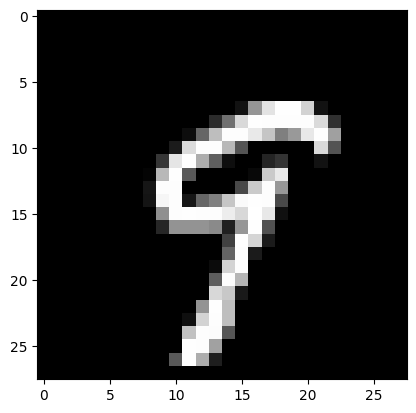

In [ ]:
rand = np.random.default_rng().integers(low=0, high=59999, size=1)
mnist_image = x_train[rand, :].reshape(28, 28)

fig, ax = plt.subplots()
ax.imshow(mnist_image, cmap="gray")


# 2. Pre-process the data

## Scaling
Normalize the image's data

8-bit integers [0, 255] -> floating-point [0, 1] interval divided by 255

In [ ]:
print('Data type of:\n* Training images: {training_images}\n* Test images: {test_images}'.format(training_images=x_train.dtype, test_images=x_test.dtype))

Data type of:
* Training images: uint8
* Test images: uint8


In [ ]:
training_sample = 1000
test_sample = 1000

training_images = x_train[0:training_sample] / 255
test_images = x_test[0:test_sample] / 255

In [ ]:
print('Data type of:\n* Training images: {training_images}\n* Test images: {test_images}'.format(training_images=training_images.dtype, test_images=test_images.dtype))

# print(f"Original image: {x_train[0]}\nTraining image: {training_images[0]}")

Data type of:
* Training images: float64
* Test images: float64


## One-hot encoding
Transform floating point class labels into binary vector

Create 10D all-zero vector (number labels 0 to 9)

In [ ]:
print('Data type of: \n* Training labels: {training_labels}\n* Test labels: {test_labels}'.format(training_labels=y_train.dtype, test_labels=y_test.dtype))

Data type of: 
* Training labels: uint8
* Test labels: uint8


In [ ]:
def one_hot_encoding(labels, dimension=10):
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]

    return one_hot_labels.astype(np.float64)

In [ ]:
training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])

In [ ]:
print('Data type of: \n* Training labels: {training_labels}\n* Test labels: {test_labels}'.format(training_labels=training_labels.dtype, test_labels=test_labels.dtype))

print("\nOrginals vs Training labels")
for i in range(0, 3):
  print(f"    {y_train[i]}       {training_labels[i]}")

Data type of: 
* Training labels: float64
* Test labels: float64

Orginals vs Training labels
    5       [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
    0       [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
    4       [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


# Crear modelo

In [ ]:
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(784,)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,514 (240.29 KB)

 Trainable params: 61,514 (240.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model...")

Training model...


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model re-compiled with 'categorical_crossentropy' loss.")

model.fit(training_images, training_labels, epochs=5, validation_data=(test_images, test_labels))

Model re-compiled with 'categorical_crossentropy' loss.
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.4550 - loss: 1.7565 - val_accuracy: 0.6920 - val_loss: 0.9903
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7770 - loss: 0.7233 - val_accuracy: 0.8060 - val_loss: 0.5930
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8500 - loss: 0.4508 - val_accuracy: 0.8370 - val_loss: 0.4524
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8940 - loss: 0.3328 - val_accuracy: 0.8690 - val_loss: 0.4039
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9160 - loss: 0.2575 - val_accuracy: 0.9040 - val_loss: 0.2978


In [ ]:
model.save('cardui_mnist_cnn.keras')
print("Model saved successfully as: cardui_mnist_cnn.keras")

Model saved successfully as: cardui_mnist_cnn.keras


# Recognize characters via camera

In [70]:
model = tf.keras.models.load_model('cardui_mnist_cnn.keras')

cap = cv2.VideoCapture(0)
